Cluster Summary:
          Total_usage_minutes  Frequency  Monetary       CLV
Cluster                                                    
0                     591.01     270.29     59.48  16081.01
1                     516.77     321.14     50.80  16362.71
2                     679.48     322.75     69.65  22431.20


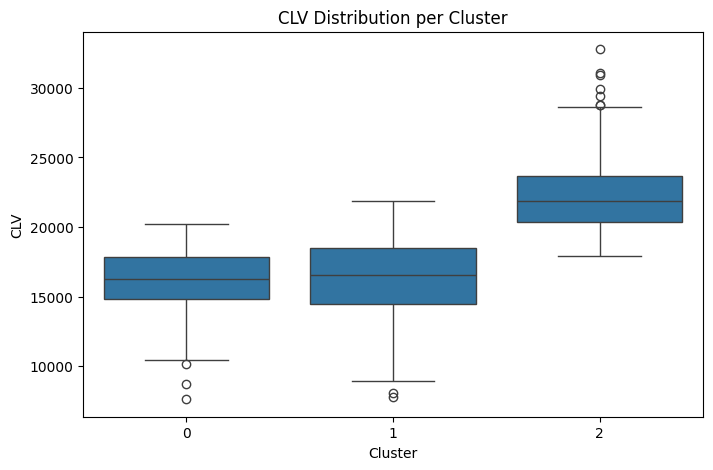

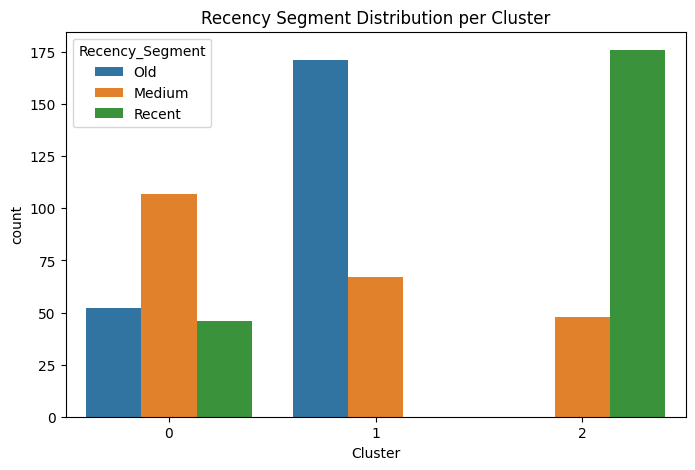

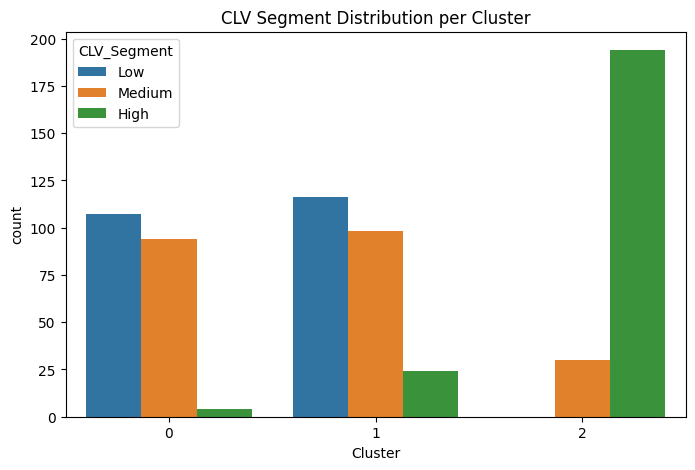

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("processed_feature_engineered_data.csv")  

data['Total_usage_minutes'] = data['Total day minutes'] + data['Total eve minutes'] + data['Total night minutes'] + data['Total intl minutes']

data['Recency_Segment'] = pd.qcut(data['Total_usage_minutes'], 3, labels=['Old', 'Medium', 'Recent'])

data['Monetary'] = data['Total day charge'] + data['Total eve charge'] + data['Total night charge'] + data['Total intl charge']

data['Frequency'] = data['Total day calls'] + data['Total eve calls'] + data['Total night calls'] + data['Total intl calls']

data['CLV'] = data['Monetary'] * data['Frequency']

data['CLV_Segment'] = pd.qcut(data['CLV'], 3, labels=['Low', 'Medium', 'High'])

rfm_features = data[['Total_usage_minutes', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = data.groupby('Cluster').agg({
    'Total_usage_minutes':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'CLV':'mean'
}).round(2)

print("Cluster Summary:\n", cluster_summary)

plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='CLV', data=data)
plt.title('CLV Distribution per Cluster')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', hue='Recency_Segment', data=data)
plt.title('Recency Segment Distribution per Cluster')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', hue='CLV_Segment', data=data)
plt.title('CLV Segment Distribution per Cluster')
plt.show()